## Entropy

In [1]:
import numpy as np 
from math import log
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#only 2 class
def E(a,b):
    if a == 0 or b ==0:
        return 0
    probs_a = a / (a+b)
    probs_b = b / (a+b)
    #Compute entropy
    ent = -(probs_a * log(probs_a,2) + probs_b * log(probs_b,2))
    
    return ent


In [3]:
S=E(9,5)
S

0.9402859586706309

### Outlook Gain

In [4]:
S-(5/14*E(3,2)+4/14*E(4,0)+5/14*E(2,3))

0.2467498197744391

### Temp Gain

In [5]:
S-(4/14*E(2,2)+6/14*E(4,2)+4/14*E(3,1))

0.029222565658954647

### HumilityGain

In [6]:
S- (7/14*E(3,4)+7/14*E(6,1))

0.15183550136234136

### Windy Gain

In [7]:
S-(8/14*E(6,2)+6/14*E(3,3))

0.04812703040826927

## Exercise :
    Outlook= rain 
    試著計算Temp, Humidity, Windy 的Information Gain 並畫出在Rainy下的樹狀結構
 
    
   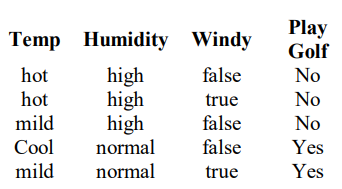

In [8]:
# Outlook = rain subset entropy (yes=3, no=2)
rain_entropy = E(3, 2)
rain_entropy

0.9709505944546686

In [9]:
# Temp gain for Outlook = rain
# mild: yes=2, no=1; cool: yes=1, no=1
rain_entropy - (3/5*E(2, 1) + 2/5*E(1, 1))

0.01997309402197489

In [10]:
# Humidity gain for Outlook = rain
# high: yes=1, no=1; normal: yes=2, no=1
rain_entropy - (2/5*E(1, 1) + 3/5*E(2, 1))

0.01997309402197489

In [11]:
# Windy gain for Outlook = rain
# weak: yes=3, no=0; strong: yes=0, no=2
rain_entropy - (3/5*E(3, 0) + 2/5*E(0, 2))

0.9709505944546686

In [12]:
def entropy(labels):
    n_labels = len(labels)

    if n_labels <= 1:
        return 0

    value,counts = np.unique(labels, return_counts=True)
    print(value,counts)
    probs = counts / n_labels

    ent = 0.
    # Compute entropy
    for i in probs:
        ent -= i * log(i,2)

    return ent


labels=['yes','yes','yes']
print(entropy(labels))

labels=['yes','no','yes','no']
print(entropy(labels))

labels=['high','low','high','high','low','normal','normal','normal']
print(entropy(labels))

labels=['high','high','high','high','high','normal','normal','normal']
print(entropy(labels))

['yes'] [3]
0.0
['no' 'yes'] [2 2]
1.0
['high' 'low' 'normal'] [3 2 3]
1.5612781244591325
['high' 'normal'] [5 3]
0.9544340029249649


## ans
['yes'] [3] <br>
0.0<br>
['no' 'yes'] [2 2]<br>
1.0<br>
['high' 'low' 'normal'] [3 2 3]<br>
1.5612781244591325<br>
['high' 'normal'] [5 3]<br>
0.9544340029249649<br>


In [13]:
from scipy.stats import entropy

In [14]:
entropy([1/2, 1/2], base=2)

np.float64(1.0)

In [15]:
entropy([5/8, 3/8], base=2)

np.float64(0.954434002924965)

In [16]:
0.97 - (2/5*entropy([2,0], base=2)+2/5*entropy([1,1], base=2)+1/5*entropy([1,0], base=2))


np.float64(0.57)

Temp gain: 0.0200
Humidity gain: 0.0200
Windy gain: 0.9710
Best split under Outlook=rain: Windy


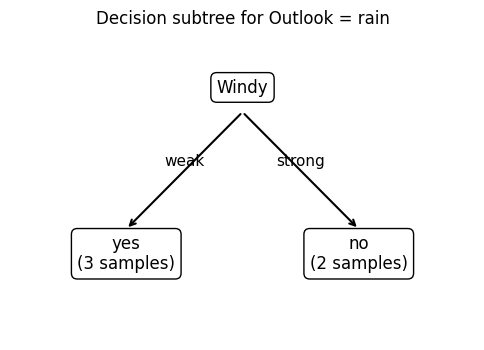

In [17]:
rain_gains = {
    'Temp': rain_entropy - (3/5*E(2, 1) + 2/5*E(1, 1)),
    'Humidity': rain_entropy - (2/5*E(1, 1) + 3/5*E(2, 1)),
    'Windy': rain_entropy - (3/5*E(3, 0) + 2/5*E(0, 2)),
}

for feature, gain in rain_gains.items():
    print(f'{feature} gain: {gain:.4f}')

best_feature = max(rain_gains, key=rain_gains.get)
print('Best split under Outlook=rain:', best_feature)

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')

nodes = {
    'root': (0.5, 0.82, 'Windy'),
    'weak': (0.25, 0.28, 'yes\n(3 samples)'),
    'strong': (0.75, 0.28, 'no\n(2 samples)'),
}

for _, (x, y, label) in nodes.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='black'))

for child, edge_label in [('weak', 'weak'), ('strong', 'strong')]:
    x0, y0, _ = nodes['root']
    x1, y1, _ = nodes[child]
    ax.annotate('', xy=(x1, y1 + 0.08), xytext=(x0, y0 - 0.08),
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.03, edge_label,
            ha='center', va='center', fontsize=11)

ax.set_title('Decision subtree for Outlook = rain')
plt.show()